In [8]:
import torch
import emlp.nn.pytorch as nn
from emlp.groups import SO13
import numpy as np
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from emlp.datasets import ParticleInteraction

In [9]:
trainset = ParticleInteraction(300) # Initialize dataset with 1000 examples
testset = ParticleInteraction(1000)

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size=500
lr=3e-3
max_epochs=500

group = SO13()
num_layers = 3
ch = 3

In [11]:
net = nn.MLP
net = nn.EMLP

model = net(trainset.rep_in,trainset.rep_out,group=group,num_layers=num_layers,ch=ch).to(device)

In [12]:
x = torch.randn(batch_size,trainset[0][0].size).to(device) # generate some random data
print(x.dtype)

model(x)

torch.float32


tensor([[-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.2137],
        [-0.

In [20]:
for name, p in model.named_parameters():
    print(name, p.size(), p.requires_grad)

network.0.linear.weight torch.Size([3, 16]) True
network.0.linear.bias torch.Size([3]) True
network.0.bilinear.bi_params torch.Size([0]) True
network.1.linear.weight torch.Size([3, 3]) True
network.1.linear.bias torch.Size([3]) True
network.1.bilinear.bi_params torch.Size([0]) True
network.2.linear.weight torch.Size([3, 3]) True
network.2.linear.bias torch.Size([3]) True
network.2.bilinear.bi_params torch.Size([0]) True
network.3.weight torch.Size([1, 3]) True
network.3.bias torch.Size([1]) True


In [13]:
optimizer = torch.optim.Adam(model.parameters(),lr=lr)
trainloader = DataLoader(trainset,batch_size=batch_size,shuffle=True)
testloader = DataLoader(testset,batch_size=batch_size,shuffle=True)

def loss(x, y):
    x, y = x.float(), y.float()
    yhat = model(x.to(device))
    return ((yhat-y.to(device))**2).mean()

def train_op(x, y):
    optimizer.zero_grad()
    lossval = loss(x,y)
    lossval.backward()
    optimizer.step()
    return lossval


test_losses = []
train_losses = []
for epoch in tqdm(range(max_epochs)):
    train_losses.append(np.mean([train_op(*mb).cpu().data.numpy() for mb in trainloader]))
    if not epoch%10:
        with torch.no_grad():
            test_losses.append(np.mean([loss(*mb).cpu().data.numpy() for mb in testloader]))

100%|██████████| 500/500 [00:04<00:00, 120.63it/s]


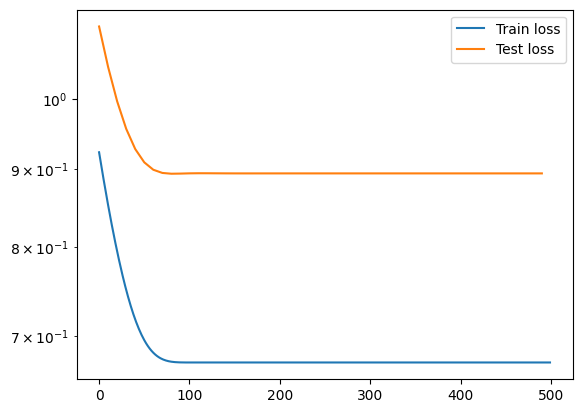

In [14]:
import matplotlib.pyplot as plt
plt.plot(np.arange(max_epochs),train_losses,label='Train loss')
plt.plot(np.arange(0,max_epochs,10),test_losses,label='Test loss')
plt.legend()
plt.yscale('log')